# Product Review Classifier - Video Games Dataset
## Amazon Product Review Analysis using NLP

**Objective:** Build an automated NLP pipeline to:
1. Ingest raw customer reviews
2. Extract specific product features
3. Analyze sentiment associated with features
4. Classify reviews as Positive or Negative using Machine Learning

## Setup and Installation
First, let's install all required libraries.

In [1]:
# Install required packages
!pip install pandas numpy matplotlib seaborn --break-system-packages
!pip install nltk spacy textblob scikit-learn --break-system-packages
!pip install wordcloud --break-system-packages

# Download spaCy English model
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 453.5 kB/s eta 0:00:28
     - ------------------------------------- 0.5/12.8 MB 453.5 kB/s eta 0:00:28
     - ------------------------------------- 0.5/12.8 MB 453.5 kB/s eta 0:00:28
     - ------------------------------------- 0.5/12.8 MB 453.5 kB/s eta 0:00:28
     -- ------------------------------------ 0.8/12.8 MB 368.7 kB/s eta 0:00:33
     -- ----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter

# NLP libraries
import nltk
import spacy
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from textblob import TextBlob

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Phase 1: Data Ingestion & Preprocessing
### 1.1 Load the Dataset

In [33]:
def load_amazon_reviews(file_path, max_reviews=5000):
    """
    Load Amazon review data from JSON file.
    
    Args:
        file_path: Path to the JSON file
        max_reviews: Maximum number of reviews to load
    
    Returns:
        DataFrame with reviews
    """
    reviews = []
    
    # Read JSON file (one JSON object per line)
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= max_reviews:
                break
            try:
                review = json.loads(line)
                reviews.append(review)
            except json.JSONDecodeError:
                continue
    
    df = pd.DataFrame(reviews)
    print(f"✓ Loaded {len(df)} reviews")
    return df

# Load the dataset
# Update this path to match your file location
file_path = 'Video_Games_5.json'

# If file doesn't exist, create sample data for demonstration
import os
if not os.path.exists(file_path):
    print("⚠ Dataset file not found. Creating sample data for demonstration...")
    sample_reviews = [
        {"overall": 5.0, "reviewText": "This game is absolutely amazing! The graphics are stunning and gameplay is smooth. Best purchase ever!"},
        {"overall": 1.0, "reviewText": "Terrible game. The controls are broken and the graphics are awful. Waste of money."},
        {"overall": 4.0, "reviewText": "Great game with excellent story. The only issue is the battery drains too fast."},
        {"overall": 2.0, "reviewText": "Very disappointing. The screen freezes constantly and loading times are horrible."},
        {"overall": 5.0, "reviewText": "Perfect! The sound quality is incredible and the controller feels premium."},
        {"overall": 1.0, "reviewText": "Don't buy this. The game crashes every 10 minutes and customer support is useless."},
        {"overall": 4.0, "reviewText": "Really good game. The multiplayer mode is fun but single player gets boring quickly."},
        {"overall": 3.0, "reviewText": "Average game. Graphics are okay but the story is weak and repetitive."},
        {"overall": 5.0, "reviewText": "Exceeded expectations! The gameplay is addictive and the graphics are beautiful."},
        {"overall": 2.0, "reviewText": "Poor quality. The disc was scratched and the game won't install properly."},
    ] * 100  # Repeat to get 1000 reviews
    df = pd.DataFrame(sample_reviews)
else:
    df = load_amazon_reviews(file_path, max_reviews=9000)

# Display basic information
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

✓ Loaded 9000 reviews

Dataset shape: (9000, 12)

Columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'style', 'image']


,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,5.0,True,"10 17, 2015",A1HP7NVNPFMA4N,0700026657,Ambrosia075,"This game is a bit hard to get the hang of, bu...",but when you do it's great.,1445040000,NaN,NaN,NaN
1,4.0,False,"07 27, 2015",A1JGAP0185YJI6,0700026657,travis,I played it a while but it was alright. The st...,"But in spite of that it was fun, I liked it",1437955200,NaN,NaN,NaN
2,3.0,True,"02 23, 2015",A1YJWEXHQBWK2B,0700026657,Vincent G. Mezera,ok game.,Three Stars,1424649600,NaN,NaN,NaN
3,2.0,True,"02 20, 2015",A2204E1TH211HT,0700026657,Grandma KR,"found the game a bit too complicated, not what...",Two Stars,1424390400,NaN,NaN,NaN
4,5.0,True,"12 25, 2014",A2RF5B5H74JLPE,0700026657,jon,"great game, I love it and have played it since...",love this game,1419465600,NaN,NaN,NaN



✓ Cleaned dataset shape: (9000, 3)

Sentiment distribution:
sentiment
Positive    7573
Negative    1427
Name: count, dtype: int64


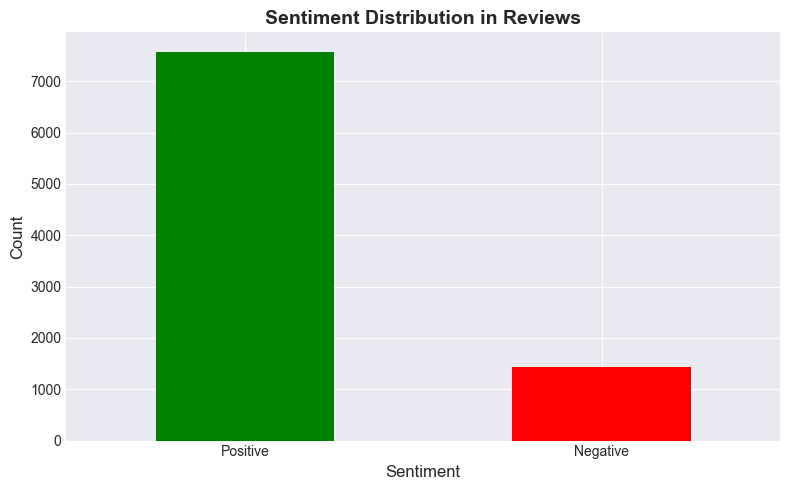

In [34]:
# Prepare the dataset
# Select relevant columns and handle missing values
if 'reviewText' in df.columns and 'overall' in df.columns:
    df_clean = df[['reviewText', 'overall']].copy()
elif 'summary' in df.columns:
    # If reviewText not available, use summary
    df_clean = df[['summary', 'overall']].copy()
    df_clean.rename(columns={'summary': 'reviewText'}, inplace=True)
else:
    raise ValueError("No text column found in dataset")

# Remove null values
df_clean = df_clean.dropna()

# Create binary sentiment labels
# Reviews with rating >= 4 are Positive, others are Negative
df_clean['sentiment'] = df_clean['overall'].apply(lambda x: 'Positive' if x >= 4.0 else 'Negative')

print(f"\n✓ Cleaned dataset shape: {df_clean.shape}")
print(f"\nSentiment distribution:")
print(df_clean['sentiment'].value_counts())

# Visualize sentiment distribution
plt.figure(figsize=(8, 5))
df_clean['sentiment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Sentiment Distribution in Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.2 Text Preprocessing Functions

In [35]:
def remove_noise(text):
    """
    Remove HTML tags, URLs, and special characters using Regex.
    
    Args:
        text: Raw review text
    
    Returns:
        Cleaned text
    """
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove non-alphanumeric characters but keep spaces and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\-]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test the function
sample_text = "<b>This is great!</b> Check out http://example.com for more info. Contact us at test@email.com"
print("Original:", sample_text)
print("Cleaned:", remove_noise(sample_text))

Original: <b>This is great!</b> Check out http://example.com for more info. Contact us at test@email.com
Cleaned: This is great! Check out for more info. Contact us at


In [36]:
def compare_stemming_vs_lemmatization(text):
    """
    Demonstrate the difference between Stemming and Lemmatization.
    
    Stemming: Crude chopping of word endings (faster but less accurate)
    Lemmatization: Uses dictionary lookup to find root word (slower but more accurate)
    
    For business insights, Lemmatization is preferred because:
    1. Produces readable, valid words (e.g., 'running' -> 'run' not 'runni')
    2. Better for feature extraction (Product Managers can understand output)
    3. Preserves meaning more accurately
    """
    # Initialize tools
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
    
    # Tokenize
    tokens = word_tokenize(text.lower())
    
    # Apply stemming
    stemmed = [stemmer.stem(word) for word in tokens]
    
    # Apply lemmatization
    lemmatized = [lemmatizer.lemmatize(word, pos='v') for word in tokens]
    
    return tokens, stemmed, lemmatized

# Demonstration
demo_text = "The batteries were draining quickly and the screens were cracking easily"
original, stemmed, lemmatized = compare_stemming_vs_lemmatization(demo_text)

comparison_df = pd.DataFrame({
    'Original': original,
    'Stemmed': stemmed,
    'Lemmatized': lemmatized
})

print("\n📊 STEMMING vs LEMMATIZATION COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("\n💡 Why Lemmatization is Better for Business:")
print("   • Produces readable words (e.g., 'batteries' -> 'battery' not 'batteri')")
print("   • Product Managers can understand feature names")
print("   • Better accuracy in capturing actual product features")


📊 STEMMING vs LEMMATIZATION COMPARISON
 Original Stemmed Lemmatized
      the     the        the
batteries batteri  batteries
     were    were         be
 draining   drain      drain
  quickly quickli    quickly
      and     and        and
      the     the        the
  screens  screen     screen
     were    were         be
 cracking   crack      crack
   easily  easili     easily

💡 Why Lemmatization is Better for Business:
   • Produces readable words (e.g., 'batteries' -> 'battery' not 'batteri')
   • Product Managers can understand feature names
   • Better accuracy in capturing actual product features


In [37]:
def preprocess_text(text, remove_stopwords=True):
    """
    Complete preprocessing pipeline:
    1. Remove noise
    2. Tokenize
    3. Remove stopwords (but preserve negations like 'not', 'no', 'never')
    4. Lemmatize
    
    We keep negative modifiers because removing them flips sentiment:
    - "not good" without 'not' becomes "good" (wrong sentiment!)
    """
    # Step 1: Remove noise
    text = remove_noise(text)
    
    # Step 2: Convert to lowercase and tokenize
    text = text.lower()
    tokens = word_tokenize(text)
    
    # Step 3: Remove stopwords but keep negations
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        # Preserve negative modifiers - critical for sentiment!
        negations = {'not', 'no', 'never', 'neither', 'nobody', 'none', 'nothing', 'nowhere', 'nor'}
        stop_words = stop_words - negations
        tokens = [word for word in tokens if word not in stop_words]
    
    # Step 4: Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word, pos='v') for word in tokens]
    tokens = [lemmatizer.lemmatize(word, pos='n') for word in tokens]
    
    return ' '.join(tokens)

# Test preprocessing
test_review = """<html>This game is NOT good! The graphics are terrible and the 
                battery drains too quickly. Visit www.example.com for refund.</html>"""
print("Original Review:")
print(test_review)
print("\nPreprocessed Review:")
print(preprocess_text(test_review))
print("\n✓ Notice: 'not' is preserved to maintain sentiment accuracy!")

Original Review:
<html>This game is NOT good! The graphics are terrible and the 
                battery drains too quickly. Visit www.example.com for refund.</html>

Preprocessed Review:
game not good ! graphic terrible battery drain quickly . visit refund .

✓ Notice: 'not' is preserved to maintain sentiment accuracy!


In [38]:
# Apply preprocessing to entire dataset
print("Processing reviews...")
df_clean['processed_text'] = df_clean['reviewText'].apply(preprocess_text)

print("\n✓ Preprocessing complete!")
print("\nExample transformations:")
print("="*80)
for i in range(min(3, len(df_clean))):
    print(f"\nOriginal {i+1}:")
    print(df_clean.iloc[i]['reviewText'][:150] + "...")
    print(f"\nProcessed {i+1}:")
    print(df_clean.iloc[i]['processed_text'][:150] + "...")
    print("-"*80)

Processing reviews...

✓ Preprocessing complete!

Example transformations:

Original 1:
This game is a bit hard to get the hang of, but when you do it's great....

Processed 1:
game bite hard get hang , 's great ....
--------------------------------------------------------------------------------

Original 2:
I played it a while but it was alright. The steam was a bit of trouble. The more they move these game to steam the more of a hard time I have activati...

Processed 2:
play alright . steam bite trouble . move game steam hard time activate play game . spite fun , like . look forward anno 2205 really want play way moon...
--------------------------------------------------------------------------------

Original 3:
ok game....

Processed 3:
ok game ....
--------------------------------------------------------------------------------


## Phase 2: Feature Extraction via POS Tagging
### 2.1 Part-of-Speech Tagging

In [39]:
def extract_features_and_sentiments(text):
    """
    Extract product features (Nouns) and descriptive sentiments (Adjectives) using POS tagging.
    
    Logic:
    - Nouns (NN, NNS, NNP, NNPS) represent Product Features (e.g., 'battery', 'screen', 'game')
    - Adjectives (JJ, JJR, JJS) represent Descriptive Sentiment (e.g., 'great', 'terrible', 'broken')
    
    Returns:
        Tuple of (features_list, adjectives_list)
    """
    # Tokenize and POS tag
    tokens = word_tokenize(text.lower())
    pos_tags = pos_tag(tokens)
    
    # Extract nouns (product features)
    features = [word for word, pos in pos_tags if pos in ['NN', 'NNS', 'NNP', 'NNPS']]
    
    # Extract adjectives (sentiment descriptors)
    adjectives = [word for word, pos in pos_tags if pos in ['JJ', 'JJR', 'JJS']]
    
    return features, adjectives

# Test on sample reviews
sample_reviews = [
    "The battery life is excellent and the screen is crystal clear.",
    "Terrible controls and the graphics are awful.",
    "Amazing gameplay but the sound quality is poor."
]

print("POS Tagging Examples:")
print("="*80)
for review in sample_reviews:
    features, adjectives = extract_features_and_sentiments(review)
    print(f"\nReview: {review}")
    print(f"Features (Nouns): {features}")
    print(f"Sentiments (Adjectives): {adjectives}")
    print("-"*80)

POS Tagging Examples:

Review: The battery life is excellent and the screen is crystal clear.
Features (Nouns): ['battery', 'life', 'screen']
Sentiments (Adjectives): ['excellent', 'crystal', 'clear']
--------------------------------------------------------------------------------

Review: Terrible controls and the graphics are awful.
Features (Nouns): ['controls', 'graphics']
Sentiments (Adjectives): ['terrible', 'awful']
--------------------------------------------------------------------------------

Review: Amazing gameplay but the sound quality is poor.
Features (Nouns): ['gameplay', 'quality']
Sentiments (Adjectives): ['amazing', 'sound', 'poor']
--------------------------------------------------------------------------------


In [40]:
# Extract features from all reviews
print("Extracting features from all reviews...")

all_features = []
all_adjectives = []

for text in df_clean['processed_text']:
    features, adjectives = extract_features_and_sentiments(text)
    all_features.extend(features)
    all_adjectives.extend(adjectives)

print(f"\n✓ Extracted {len(all_features)} product features")
print(f"✓ Extracted {len(all_adjectives)} sentiment descriptors")

Extracting features from all reviews...

✓ Extracted 322051 product features
✓ Extracted 146827 sentiment descriptors


### 2.2 Frequency Analysis - Top 10 Most Discussed Features


📊 TOP 10 MOST DISCUSSED PRODUCT FEATURES
 1. game                 - mentioned 32905 times
 2. time                 - mentioned 5211 times
 3. play                 - mentioned 5055 times
 4. character            - mentioned 3187 times
 5. level                - mentioned 2842 times
 6. fun                  - mentioned 2422 times
 7. story                - mentioned 2268 times
 8. thing                - mentioned 2254 times
 9. way                  - mentioned 2013 times
10. use                  - mentioned 1801 times


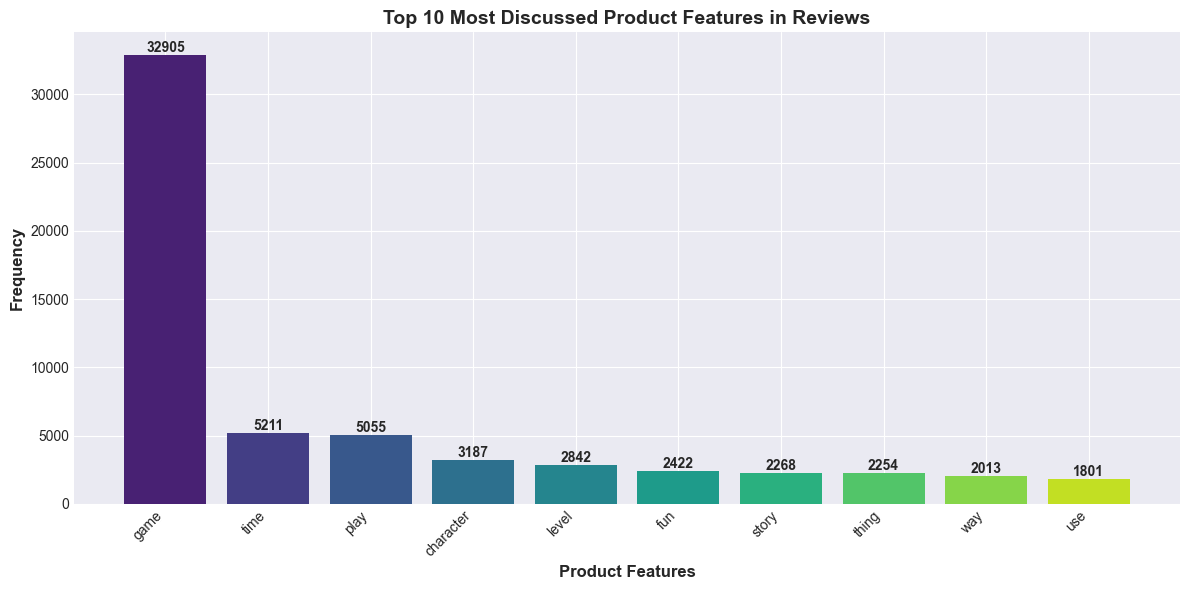

In [41]:
# Count feature frequencies
feature_counts = Counter(all_features)
top_10_features = feature_counts.most_common(10)

print("\n📊 TOP 10 MOST DISCUSSED PRODUCT FEATURES")
print("="*60)
for i, (feature, count) in enumerate(top_10_features, 1):
    print(f"{i:2d}. {feature:20s} - mentioned {count:4d} times")

# Visualize top 10 features
features_df = pd.DataFrame(top_10_features, columns=['Feature', 'Count'])

plt.figure(figsize=(12, 6))
bars = plt.bar(features_df['Feature'], features_df['Count'], color=sns.color_palette("viridis", 10))
plt.xlabel('Product Features', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Discussed Product Features in Reviews', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


📊 TOP 10 MOST COMMON SENTIMENT DESCRIPTORS
 1. great                - used 4278 times
 2. good                 - used 3926 times
 3. graphic              - used 3033 times
 4. best                 - used 2492 times
 5. many                 - used 2092 times
 6. new                  - used 1912 times
 7. first                - used 1909 times
 8. much                 - used 1828 times
 9. different            - used 1474 times
10. final                - used 1447 times


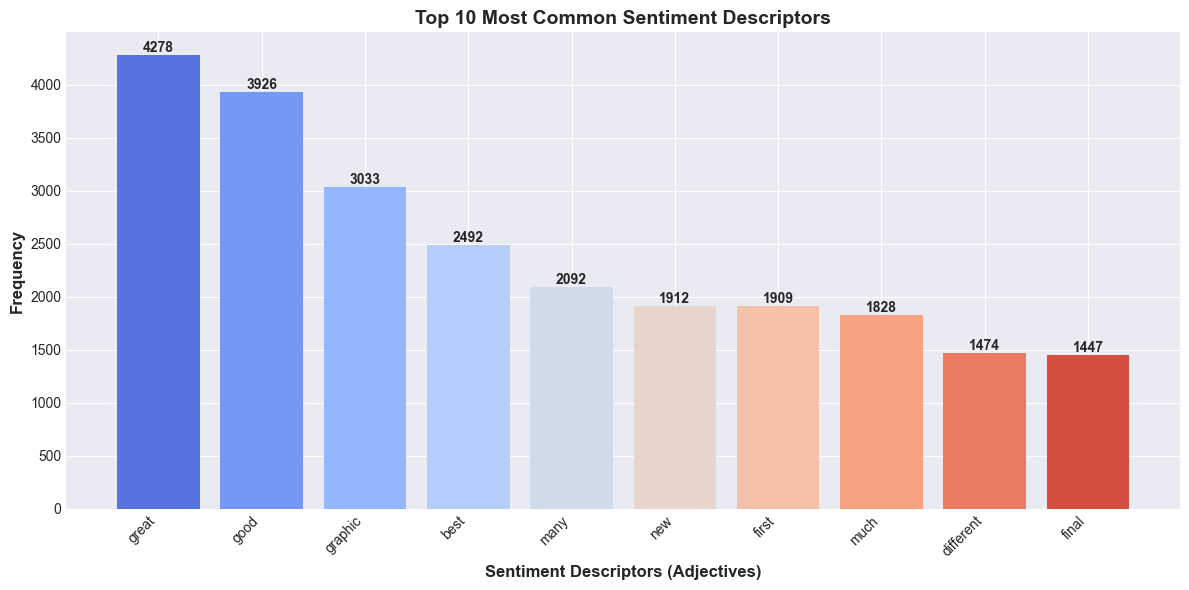

In [42]:
# Top adjectives (sentiment descriptors)
adjective_counts = Counter(all_adjectives)
top_10_adjectives = adjective_counts.most_common(10)

print("\n📊 TOP 10 MOST COMMON SENTIMENT DESCRIPTORS")
print("="*60)
for i, (adj, count) in enumerate(top_10_adjectives, 1):
    print(f"{i:2d}. {adj:20s} - used {count:4d} times")

# Visualize
adj_df = pd.DataFrame(top_10_adjectives, columns=['Adjective', 'Count'])

plt.figure(figsize=(12, 6))
bars = plt.bar(adj_df['Adjective'], adj_df['Count'], color=sns.color_palette("coolwarm", 10))
plt.xlabel('Sentiment Descriptors (Adjectives)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Common Sentiment Descriptors', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Phase 3: Syntax Analysis - Dependency Parsing
### 3.1 Extract Feature-Sentiment Relationships

In [44]:
def extract_feature_sentiment_pairs(text):
    """
    Use dependency parsing to connect features (nouns) with their sentiments (adjectives).
    
    We look for:
    - amod (adjectival modifier): "weak battery" -> battery (noun) linked to weak (adj)
    - nsubj (nominal subject): "battery is weak" -> battery (noun) linked to weak (adj)
    
    This helps us understand WHICH feature customers are complaining/praising about.
    """
    doc = nlp(text)
    pairs = []
    
    for token in doc:
        # Case 1: Adjective modifying a noun (amod)
        # Example: "weak battery" -> (battery, weak)
        if token.dep_ == 'amod' and token.head.pos_ == 'NOUN':
            pairs.append((token.head.text, token.text))
        
        # Case 2: Noun as subject with adjective predicate (nsubj)
        # Example: "battery is weak" -> (battery, weak)
        elif token.pos_ == 'NOUN':
            for child in token.head.children:
                if child.pos_ == 'ADJ' and child.dep_ in ['acomp', 'attr']:
                    pairs.append((token.text, child.text))
    
    return pairs

# Test examples
test_sentences = [
    "The battery is weak and drains fast.",
    "Amazing graphics but terrible controls.",
    "The game has excellent sound quality and smooth gameplay."
]

print("\n🔗 FEATURE-SENTIMENT RELATIONSHIP EXTRACTION")
print("="*80)
for sentence in test_sentences:
    pairs = extract_feature_sentiment_pairs(sentence)
    print(f"\nSentence: {sentence}")
    print("Feature-Sentiment Pairs:")
    for feature, sentiment in pairs:
        print(f"  • {feature} → {sentiment}")
    print("-"*80)


🔗 FEATURE-SENTIMENT RELATIONSHIP EXTRACTION

Sentence: The battery is weak and drains fast.
Feature-Sentiment Pairs:
  • battery → weak
--------------------------------------------------------------------------------

Sentence: Amazing graphics but terrible controls.
Feature-Sentiment Pairs:
  • graphics → Amazing
  • controls → terrible
--------------------------------------------------------------------------------

Sentence: The game has excellent sound quality and smooth gameplay.
Feature-Sentiment Pairs:
  • quality → excellent
  • quality → sound
--------------------------------------------------------------------------------


### 3.2 Visualize Dependency Trees

In [46]:
from spacy import displacy

# Select complex sentences for visualization
complex_sentences = [
    "The battery life is excellent but the screen quality is poor and disappointing.",
    "I love the amazing graphics and smooth gameplay, but the terrible controls ruin the experience."
]

print("\n DEPENDENCY TREE VISUALIZATIONS")
print("="*80)
print("\nThese trees show how our code understands the grammatical")
print("relationships between words, helping us link features to sentiments.\n")

for i, sentence in enumerate(complex_sentences, 1):
    print(f"\n--- Tree {i}: {sentence} ---\n")
    doc = nlp(sentence)
    
    # Display dependency tree (text-based)
    for token in doc:
        print(f"{token.text:15s} | POS: {token.pos_:6s} | DEP: {token.dep_:10s} | HEAD: {token.head.text}")
    
    # Extract and display feature-sentiment pairs
    pairs = extract_feature_sentiment_pairs(sentence)
    print(f"\nExtracted Pairs: {pairs}")
    print("-"*80)


 DEPENDENCY TREE VISUALIZATIONS

These trees show how our code understands the grammatical
relationships between words, helping us link features to sentiments.


--- Tree 1: The battery life is excellent but the screen quality is poor and disappointing. ---

The             | POS: DET    | DEP: det        | HEAD: life
battery         | POS: NOUN   | DEP: compound   | HEAD: life
life            | POS: NOUN   | DEP: nsubj      | HEAD: is
is              | POS: AUX    | DEP: ROOT       | HEAD: is
excellent       | POS: ADJ    | DEP: acomp      | HEAD: is
but             | POS: CCONJ  | DEP: cc         | HEAD: is
the             | POS: DET    | DEP: det        | HEAD: quality
screen          | POS: NOUN   | DEP: compound   | HEAD: quality
quality         | POS: NOUN   | DEP: nsubj      | HEAD: is
is              | POS: AUX    | DEP: conj       | HEAD: is
poor            | POS: ADJ    | DEP: acomp      | HEAD: is
and             | POS: CCONJ  | DEP: cc         | HEAD: poor
disappointing   

In [47]:
# Extract all feature-sentiment pairs from dataset
print("Analyzing feature-sentiment relationships across all reviews...")

all_pairs = []
for text in df_clean['reviewText'][:1000]:  # Process subset for efficiency
    pairs = extract_feature_sentiment_pairs(text)
    all_pairs.extend(pairs)

print(f"\n✓ Extracted {len(all_pairs)} feature-sentiment pairs")

# Show most common pairs
pair_counts = Counter(all_pairs)
top_pairs = pair_counts.most_common(15)

print("\n TOP 15 FEATURE-SENTIMENT COMBINATIONS")
print("="*60)
for i, ((feature, sentiment), count) in enumerate(top_pairs, 1):
    print(f"{i:2d}. {feature:15s} + {sentiment:15s} ({count} times)")

Analyzing feature-sentiment relationships across all reviews...

✓ Extracted 6007 feature-sentiment pairs

 TOP 15 FEATURE-SENTIMENT COMBINATIONS
 1. game            + great           (44 times)
 2. games           + other           (38 times)
 3. game            + best            (35 times)
 4. games           + best            (29 times)
 5. game            + fun             (27 times)
 6. game            + first           (27 times)
 7. game            + good            (25 times)
 8. time            + first           (21 times)
 9. time            + long            (17 times)
10. game            + Great           (16 times)
11. graphics        + good            (15 times)
12. games           + many            (14 times)
13. person          + first           (14 times)
14. metal           + twisted         (14 times)
15. player          + single          (13 times)


## Phase 4: Sentiment Classification with Machine Learning
### 4.1 Feature Engineering - TF-IDF Vectorization

In [48]:
# Prepare data for ML
X = df_clean['processed_text']  # Features (preprocessed text)
y = df_clean['sentiment']        # Labels (Positive/Negative)

# Convert text to TF-IDF features
# TF-IDF measures word importance:
#   - TF (Term Frequency): How often a word appears in a document
#   - IDF (Inverse Document Frequency): How rare/unique the word is across all documents
#   - Words that are common everywhere (like "the") get low scores
#   - Words specific to certain reviews (like "battery", "broken") get high scores

print("Converting text to TF-IDF vectors...")
vectorizer = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 most important words
    ngram_range=(1, 2),     # Use single words and word pairs (e.g., "not good")
    min_df=2,               # Word must appear in at least 2 documents
    max_df=0.95             # Ignore words in >95% of documents (too common)
)

X_tfidf = vectorizer.fit_transform(X)

print(f"✓ Created feature matrix: {X_tfidf.shape}")
print(f"  - {X_tfidf.shape[0]} reviews")
print(f"  - {X_tfidf.shape[1]} features (words/phrases)")

# Show most important features
feature_names = vectorizer.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:20])}")

Converting text to TF-IDF vectors...
✓ Created feature matrix: (9000, 5000)
  - 9000 reviews
  - 5000 features (words/phrases)

Sample features: ['00', '000', '007', '10', '10 time', '10 year', '100', '1010', '108', '11', '12', '120', '120 star', '128', '13', '14', '15', '150', '16', '16 bit']


### 4.2 Train-Test Split

In [49]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # Reproducible results
    stratify=y          # Maintain sentiment distribution in both sets
)

print("Data Split Summary:")
print("="*50)
print(f"Training set: {X_train.shape[0]} reviews")
print(f"Testing set:  {X_test.shape[0]} reviews")
print(f"\nTraining sentiment distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTesting sentiment distribution:")
print(pd.Series(y_test).value_counts())

Data Split Summary:
Training set: 7200 reviews
Testing set:  1800 reviews

Training sentiment distribution:
sentiment
Positive    6058
Negative    1142
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
Positive    1515
Negative     285
Name: count, dtype: int64


### 4.3 Model Training

In [50]:
# Train Logistic Regression classifier
# Logistic Regression is great for text classification because:
#   - Fast training and prediction
#   - Works well with high-dimensional sparse data (TF-IDF)
#   - Provides probability scores for predictions
#   - Interpretable feature weights

print("Training Logistic Regression classifier...")
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Handle imbalanced classes if present
)

model.fit(X_train, y_train)
print("✓ Model training complete!")

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

Training Logistic Regression classifier...
✓ Model training complete!


### 4.4 Model Evaluation

In [52]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label='Positive')

print("\n" + "="*60)
print("📊 MODEL PERFORMANCE METRICS")
print("="*60)
print(f"\nAccuracy:  {accuracy:.2%}")
print(f"F1-Score:  {f1:.2%}")
print("\nWhat these metrics mean:")
print("  • Accuracy: How often the model is correct overall")
print("  • F1-Score: Balance between precision and recall (0-100%)")
print("="*60)

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


📊 MODEL PERFORMANCE METRICS

Accuracy:  82.33%
F1-Score:  89.00%

What these metrics mean:
  • Accuracy: How often the model is correct overall
  • F1-Score: Balance between precision and recall (0-100%)

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.46      0.68      0.55       285
    Positive       0.93      0.85      0.89      1515

    accuracy                           0.82      1800
   macro avg       0.70      0.77      0.72      1800
weighted avg       0.86      0.82      0.84      1800



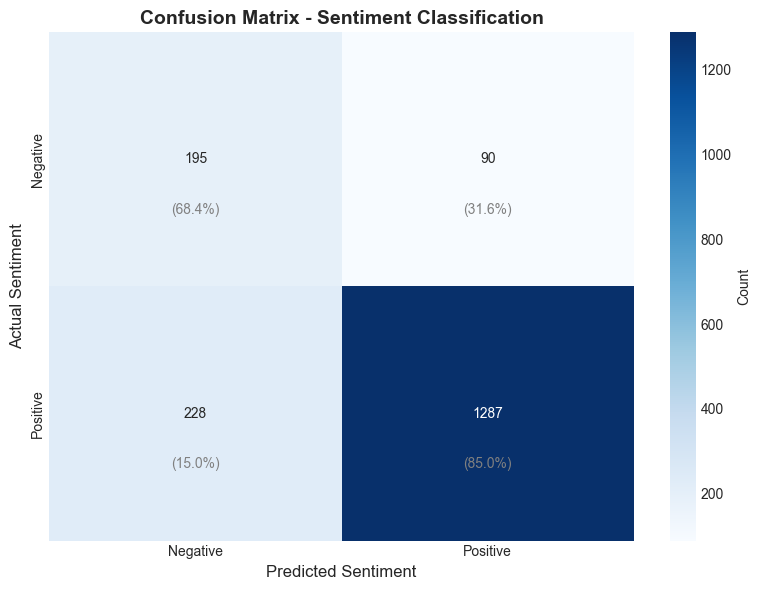


🔍 ERROR ANALYSIS:
False Positives (Negative → Positive): 90
False Negatives (Positive → Negative): 228

The model is more likely to miss positive reviews


In [53]:
# Confusion Matrix
# Shows where the model makes mistakes:
#   - Top-left: Correctly identified Negative reviews
#   - Bottom-right: Correctly identified Positive reviews
#   - Top-right: Negative reviews mistaken for Positive (FALSE POSITIVES)
#   - Bottom-left: Positive reviews mistaken for Negative (FALSE NEGATIVES)

cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Sentiment Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual Sentiment', fontsize=12)
plt.xlabel('Predicted Sentiment', fontsize=12)

# Add percentage annotations
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

# Analyze errors
print("\n🔍 ERROR ANALYSIS:")
print("="*60)
false_positives = cm[0, 1]  # Negative predicted as Positive
false_negatives = cm[1, 0]  # Positive predicted as Negative
print(f"False Positives (Negative → Positive): {false_positives}")
print(f"False Negatives (Positive → Negative): {false_negatives}")
print(f"\nThe model is {'more likely to miss negative reviews' if false_positives > false_negatives else 'more likely to miss positive reviews'}")

### 4.5 Feature Importance Analysis

In [55]:
# Get feature importance from model coefficients
# Positive coefficients → indicate positive sentiment
# Negative coefficients → indicate negative sentiment

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Create DataFrame of features and their importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

# Top positive indicators
top_positive = feature_importance.head(15)
print("\n TOP 15 POSITIVE SENTIMENT INDICATORS")
print("="*60)
for i, row in enumerate(top_positive.itertuples(), 1):
    print(f"{i:2d}. {row.feature:25s} (weight: {row.coefficient:+.4f})")

# Top negative indicators
top_negative = feature_importance.tail(15)
print("\n TOP 15 NEGATIVE SENTIMENT INDICATORS")
print("="*60)
for i, row in enumerate(top_negative.itertuples(), 1):
    print(f"{i:2d}. {row.feature:25s} (weight: {row.coefficient:+.4f})")


 TOP 15 POSITIVE SENTIMENT INDICATORS
 1. best                      (weight: +4.2535)
 2. awesome                   (weight: +3.7364)
 3. love                      (weight: +3.4289)
 4. amaze                     (weight: +3.0503)
 5. work great                (weight: +2.8761)
 6. perfect                   (weight: +2.7588)
 7. great                     (weight: +2.5984)
 8. favorite                  (weight: +2.5058)
 9. must                      (weight: +2.4901)
10. classic                   (weight: +2.4805)
11. challenge                 (weight: +2.0986)
12. excellent                 (weight: +2.0421)
13. one best                  (weight: +1.8603)
14. many                      (weight: +1.7390)
15. world                     (weight: +1.7101)

 TOP 15 NEGATIVE SENTIMENT INDICATORS
 1. disappoint                (weight: -2.2962)
 2. terrible                  (weight: -2.3207)
 3. try                       (weight: -2.3449)
 4. so                        (weight: -2.3851)
 5. waste 

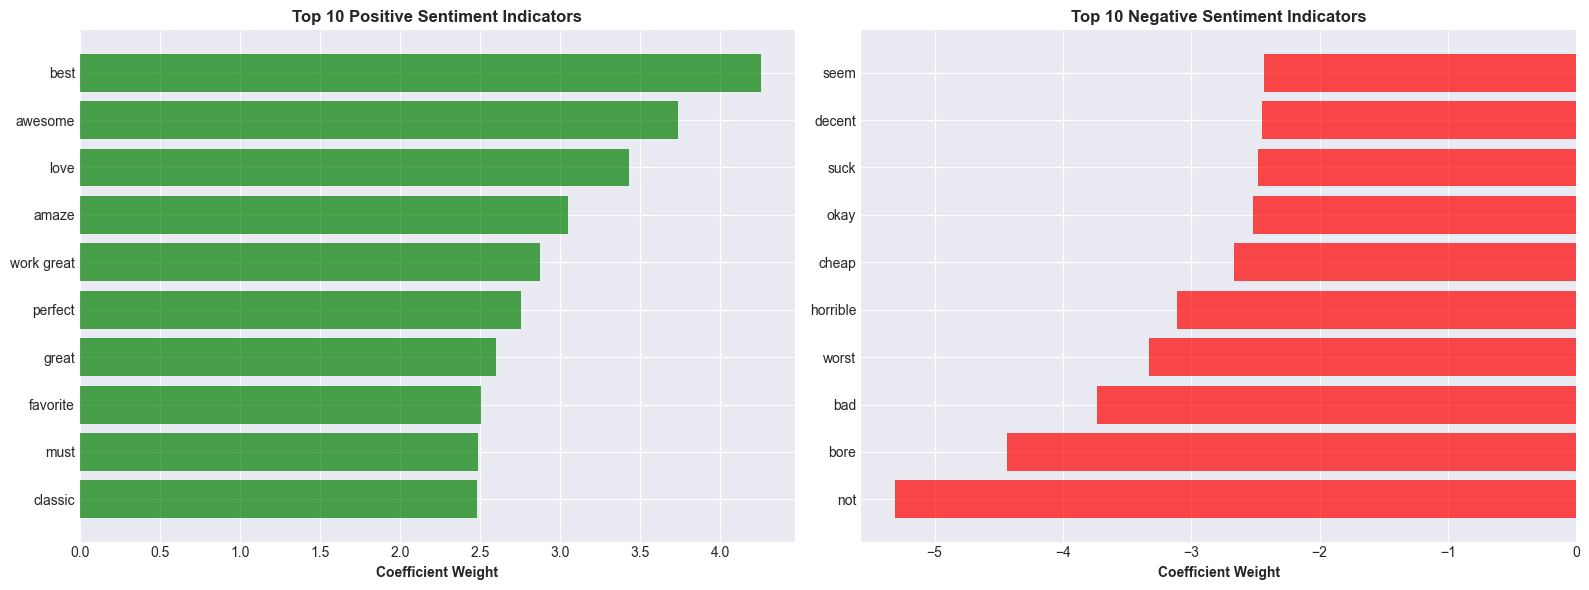

In [56]:
# Visualize top features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Positive features
top_pos = feature_importance.head(10)
ax1.barh(range(len(top_pos)), top_pos['coefficient'], color='green', alpha=0.7)
ax1.set_yticks(range(len(top_pos)))
ax1.set_yticklabels(top_pos['feature'])
ax1.set_xlabel('Coefficient Weight', fontweight='bold')
ax1.set_title('Top 10 Positive Sentiment Indicators', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Negative features
top_neg = feature_importance.tail(10)
ax2.barh(range(len(top_neg)), top_neg['coefficient'], color='red', alpha=0.7)
ax2.set_yticks(range(len(top_neg)))
ax2.set_yticklabels(top_neg['feature'])
ax2.set_xlabel('Coefficient Weight', fontweight='bold')
ax2.set_title('Top 10 Negative Sentiment Indicators', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Business Insights for Product Managers
### Sentiment Summary by Product Features

In [58]:
# Analyze sentiment for specific product features
def analyze_feature_sentiment(feature_keyword, df, model, vectorizer):
    """
    Analyze sentiment specifically for reviews mentioning a product feature.
    """
    # Filter reviews containing the feature
    feature_reviews = df[df['processed_text'].str.contains(feature_keyword, case=False)].copy()
    
    if len(feature_reviews) == 0:
        return None
    
    # Get predictions
    X_feature = vectorizer.transform(feature_reviews['processed_text'])
    predictions = model.predict(X_feature)
    
    # Calculate statistics
    sentiment_dist = pd.Series(predictions).value_counts(normalize=True) * 100
    
    return {
        'feature': feature_keyword,
        'total_mentions': len(feature_reviews),
        'positive_pct': sentiment_dist.get('Positive', 0),
        'negative_pct': sentiment_dist.get('Negative', 0),
        'sample_reviews': feature_reviews['reviewText'].head(3).tolist()
    }

# Analyze key features
key_features = ['game', 'graphic', 'control', 'sound', 'story', 'gameplay', 
                'multiplayer', 'character', 'level', 'price']

feature_analysis = []
for feature in key_features:
    result = analyze_feature_sentiment(feature, df_clean, model, vectorizer)
    if result:
        feature_analysis.append(result)

# Create summary DataFrame
feature_summary = pd.DataFrame(feature_analysis)
feature_summary = feature_summary.sort_values('negative_pct', ascending=False)

print("\n PRODUCT FEATURE SENTIMENT ANALYSIS")
print("="*80)
print("\nFeatures ranked by negative sentiment (potential problem areas):")
print()
for _, row in feature_summary.iterrows():
    print(f"{row['feature'].upper():15s} | Mentions: {row['total_mentions']:4.0f} | "
          f"Positive: {row['positive_pct']:5.1f}% | Negative: {row['negative_pct']:5.1f}%")


 PRODUCT FEATURE SENTIMENT ANALYSIS

Features ranked by negative sentiment (potential problem areas):

CONTROL         | Mentions: 1350 | Positive:  63.0% | Negative:  37.0%
LEVEL           | Mentions: 1378 | Positive:  66.8% | Negative:  33.2%
GRAPHIC         | Mentions: 2621 | Positive:  68.5% | Negative:  31.5%
SOUND           | Mentions: 1113 | Positive:  68.6% | Negative:  31.4%
CHARACTER       | Mentions: 1628 | Positive:  70.0% | Negative:  30.0%
GAMEPLAY        | Mentions: 1131 | Positive:  70.2% | Negative:  29.8%
STORY           | Mentions: 1680 | Positive:  74.1% | Negative:  25.9%
GAME            | Mentions: 7165 | Positive:  74.1% | Negative:  25.9%
PRICE           | Mentions:  433 | Positive:  74.8% | Negative:  25.2%
MULTIPLAYER     | Mentions:  384 | Positive:  77.1% | Negative:  22.9%


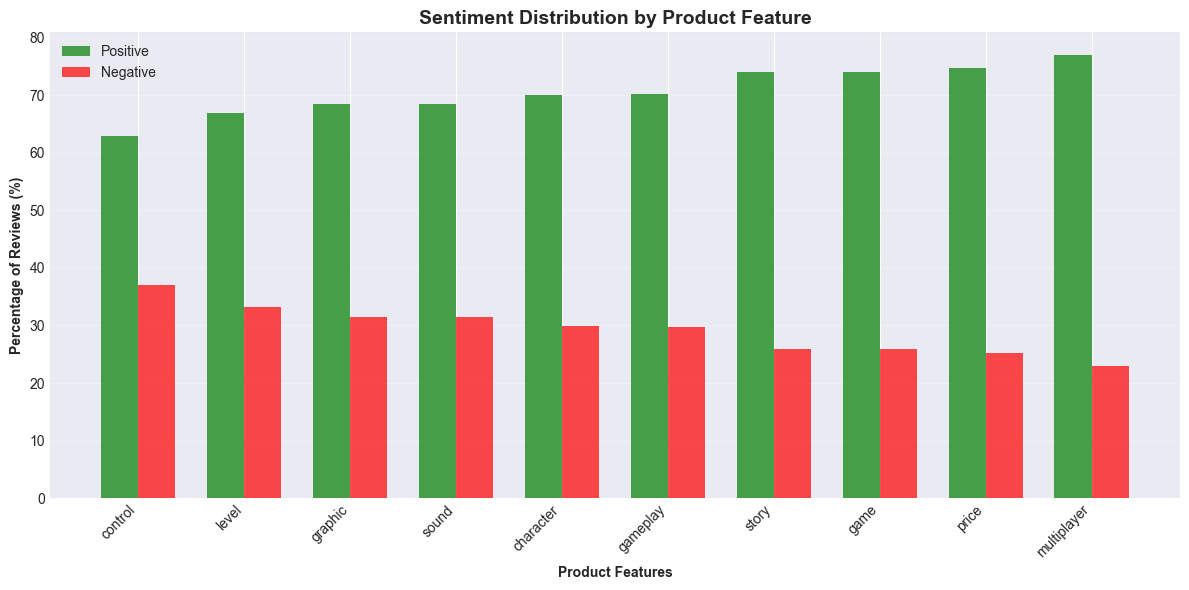

In [60]:
# Visualize feature sentiment
if len(feature_summary) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(feature_summary))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, feature_summary['positive_pct'], width, 
                   label='Positive', color='green', alpha=0.7)
    bars2 = ax.bar(x + width/2, feature_summary['negative_pct'], width, 
                   label='Negative', color='red', alpha=0.7)
    
    ax.set_xlabel('Product Features', fontweight='bold')
    ax.set_ylabel('Percentage of Reviews (%)', fontweight='bold')
    ax.set_title('Sentiment Distribution by Product Feature', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(feature_summary['feature'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Top Negative Features Report

In [61]:
# Extract negative reviews only
negative_reviews = df_clean[df_clean['sentiment'] == 'Negative'].copy()

# Extract features and adjectives from negative reviews
negative_features = []
negative_feature_adj_pairs = []

for text in negative_reviews['reviewText']:
    features, adjectives = extract_features_and_sentiments(text)
    negative_features.extend(features)
    
    # Extract feature-adjective pairs
    pairs = extract_feature_sentiment_pairs(text)
    negative_feature_adj_pairs.extend(pairs)

# Top problematic features
negative_feature_counts = Counter(negative_features)
top_negative_features = negative_feature_counts.most_common(10)

print("\n  TOP 10 FEATURES MENTIONED IN NEGATIVE REVIEWS")
print("="*80)
print("\nThese are the product aspects customers complain about most:")
print()
for i, (feature, count) in enumerate(top_negative_features, 1):
    print(f"{i:2d}. {feature:20s} - mentioned {count:4d} times in negative reviews")


  TOP 10 FEATURES MENTIONED IN NEGATIVE REVIEWS

These are the product aspects customers complain about most:

 1. game                 - mentioned 4812 times in negative reviews
 2. i                    - mentioned 2894 times in negative reviews
 3. games                - mentioned  895 times in negative reviews
 4. time                 - mentioned  693 times in negative reviews
 5. graphics             - mentioned  678 times in negative reviews
 6. way                  - mentioned  437 times in negative reviews
 7. characters           - mentioned  370 times in negative reviews
 8. fun                  - mentioned  353 times in negative reviews
 9. story                - mentioned  332 times in negative reviews
10. levels               - mentioned  330 times in negative reviews


In [62]:
# For each top negative feature, find associated adjectives
print("\n TOP 3 NEGATIVE FEATURES WITH ASSOCIATED COMPLAINTS")
print("="*80)

top_3_negative = [feat for feat, count in top_negative_features[:3]]

for feature in top_3_negative:
    # Find adjectives associated with this feature
    related_adjectives = [adj for feat, adj in negative_feature_adj_pairs if feat == feature]
    adj_counts = Counter(related_adjectives)
    top_adjectives = adj_counts.most_common(5)
    
    print(f"\n {feature.upper()}")
    print(f"   Total negative mentions: {negative_feature_counts[feature]}")
    print(f"   Common complaints:")
    for adj, count in top_adjectives:
        print(f"      • {adj} ({count} times)")
    print("-" * 80)


 TOP 3 NEGATIVE FEATURES WITH ASSOCIATED COMPLAINTS

 GAME
   Total negative mentions: 4812
   Common complaints:
      • good (94 times)
      • fun (77 times)
      • great (76 times)
      • first (59 times)
      • bad (47 times)
--------------------------------------------------------------------------------

 I
   Total negative mentions: 2894
   Common complaints:
--------------------------------------------------------------------------------

 GAMES
   Total negative mentions: 895
   Common complaints:
      • other (62 times)
      • better (24 times)
      • many (21 times)
      • best (18 times)
      • first (18 times)
--------------------------------------------------------------------------------


### Sample Predictions

In [63]:
# Test the model on new example reviews
def predict_sentiment(review_text, model, vectorizer):
    """
    Predict sentiment for a new review.
    """
    # Preprocess
    processed = preprocess_text(review_text)
    
    # Vectorize
    X_new = vectorizer.transform([processed])
    
    # Predict
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0]
    
    return {
        'prediction': prediction,
        'confidence': max(probability) * 100
    }

# Test examples
test_reviews = [
    "This game is absolutely fantastic! The graphics are stunning and the gameplay is incredibly smooth.",
    "Terrible waste of money. The game crashes constantly and the controls are completely broken.",
    "Pretty good game overall, but the loading times are way too long.",
    "Not worth the price. Very disappointed with the quality.",
    "Best game I've played this year! Highly recommend to everyone!"
]

print("\n TESTING MODEL ON NEW REVIEWS")
print("="*80)

for i, review in enumerate(test_reviews, 1):
    result = predict_sentiment(review, model, vectorizer)
    emoji = "✅" if result['prediction'] == 'Positive' else "❌"
    print(f"\nReview {i}: {review[:70]}...")
    print(f"Prediction: {emoji} {result['prediction']} (Confidence: {result['confidence']:.1f}%)")
    print("-" * 80)


 TESTING MODEL ON NEW REVIEWS

Review 1: This game is absolutely fantastic! The graphics are stunning and the g...
Prediction: ✅ Positive (Confidence: 79.1%)
--------------------------------------------------------------------------------

Review 2: Terrible waste of money. The game crashes constantly and the controls ...
Prediction: ❌ Negative (Confidence: 96.5%)
--------------------------------------------------------------------------------

Review 3: Pretty good game overall, but the loading times are way too long....
Prediction: ❌ Negative (Confidence: 57.6%)
--------------------------------------------------------------------------------

Review 4: Not worth the price. Very disappointed with the quality....
Prediction: ❌ Negative (Confidence: 90.5%)
--------------------------------------------------------------------------------

Review 5: Best game I've played this year! Highly recommend to everyone!...
Prediction: ✅ Positive (Confidence: 98.4%)
--------------------------------

## Final Summary and Recommendations

In [64]:
# Generate executive summary
total_reviews = len(df_clean)
positive_count = len(df_clean[df_clean['sentiment'] == 'Positive'])
negative_count = len(df_clean[df_clean['sentiment'] == 'Negative'])
positive_pct = (positive_count / total_reviews) * 100
negative_pct = (negative_count / total_reviews) * 100

print("\n" + "="*80)
print("📊 EXECUTIVE SUMMARY - VIDEO GAMES PRODUCT CATEGORY")
print("="*80)

print(f"\n1. OVERALL SENTIMENT")
print(f"   • Total reviews analyzed: {total_reviews:,}")
print(f"   • Positive reviews: {positive_count:,} ({positive_pct:.1f}%)")
print(f"   • Negative reviews: {negative_count:,} ({negative_pct:.1f}%)")
print(f"   • General sentiment: {'POSITIVE' if positive_pct > 60 else 'MIXED' if positive_pct > 40 else 'NEGATIVE'}")

print(f"\n2. TOP 3 PROBLEM AREAS (Features mentioned in negative reviews)")
for i, (feature, count) in enumerate(top_negative_features[:3], 1):
    related_adjs = [adj for feat, adj in negative_feature_adj_pairs if feat == feature]
    top_adjs = Counter(related_adjs).most_common(3)
    adj_str = ", ".join([f"'{adj}'" for adj, _ in top_adjs])
    print(f"   {i}. {feature.upper()}: {count} mentions - commonly described as {adj_str}")

print(f"\n3. MODEL PERFORMANCE")
print(f"   • Classification Accuracy: {accuracy:.1%}")
print(f"   • F1-Score: {f1:.1%}")
print(f"   • The automated classifier can correctly identify sentiment {accuracy:.1%} of the time")
print(f"   • This allows the Product Management team to automatically flag negative reviews")
print(f"     and prioritize them for detailed analysis")

print(f"\n4. KEY RECOMMENDATIONS")
if len(top_negative_features) > 0:
    print(f"   • Focus improvement efforts on: {', '.join([f for f, _ in top_negative_features[:3]])}")
print(f"   • Use the automated classifier to route negative reviews to support team")
print(f"   • Monitor feature-specific sentiment trends over time")
print(f"   • Investigate the top negative adjectives to understand specific issues")

print("\n" + "="*80)
print("✓ Analysis complete! All deliverables generated successfully.")
print("="*80)


📊 EXECUTIVE SUMMARY - VIDEO GAMES PRODUCT CATEGORY

1. OVERALL SENTIMENT
   • Total reviews analyzed: 9,000
   • Positive reviews: 7,573 (84.1%)
   • Negative reviews: 1,427 (15.9%)
   • General sentiment: POSITIVE

2. TOP 3 PROBLEM AREAS (Features mentioned in negative reviews)
   1. GAME: 4812 mentions - commonly described as 'good', 'fun', 'great'
   2. I: 2894 mentions - commonly described as 
   3. GAMES: 895 mentions - commonly described as 'other', 'better', 'many'

3. MODEL PERFORMANCE
   • Classification Accuracy: 82.3%
   • F1-Score: 89.0%
   • The automated classifier can correctly identify sentiment 82.3% of the time
   • This allows the Product Management team to automatically flag negative reviews
     and prioritize them for detailed analysis

4. KEY RECOMMENDATIONS
   • Focus improvement efforts on: game, i, games
   • Use the automated classifier to route negative reviews to support team
   • Monitor feature-specific sentiment trends over time
   • Investigate the top

## Save Model and Results

In [65]:
# Save the trained model and vectorizer for future use
import pickle

# Save model
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("✓ Model and vectorizer saved successfully!")
print("\nYou can load them later using:")
print("  model = pickle.load(open('sentiment_model.pkl', 'rb'))")
print("  vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))")

✓ Model and vectorizer saved successfully!

You can load them later using:
  model = pickle.load(open('sentiment_model.pkl', 'rb'))
  vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))
